# LendingClub Interest Rate Prediction — Simplified Model + Explainability

**Companion to** `FINAL_SUBMISSION.ipynb`. This notebook strips the original 4-model + aux-grade pipeline down to its load-bearing pieces, re-tunes it, and adds a full W2-style explainability section.

**What changed vs the original**

| Aspect | Original (`FINAL_SUBMISSION.ipynb`) | This notebook |
|---|---|---|
| Feature count | ~63 (50 distilled + 11 aux + 2 fico×aux) | **~38** (evidence-selected — see `MODEL_SIMPLIFICATION_REVIEW.md`) |
| Aux grade classifier | Yes (~5 min, ~0.02 pp lift) | **Dropped** (recovered via reduced FE + tuning) |
| Base learners | CB + LGB + XGB + HGB | **CB + LGB** (the two strongest, most decorrelated) |
| Tuning | Cached CB/LGB/XGB + fresh HGB Optuna (40 trials) | **Cached CB + fresh LGB Optuna (30 trials)** |
| Blend | 4-model SLSQP | 2-model SLSQP |
| Runtime | ~30-45 min | **~15-20 min** |
| Submission | `FINAL_SUBMISSION.csv` (overwritten by original) | **`FINAL_SIMPLIFIED_SUBMISSION.csv`** (separate file) |

**Expected RMSE delta**: the simplified blend lands within ~0.02-0.04 pp of the 4-model champion. The exact RMSE table is computed and printed in section 12.

**Reproducibility**: same `RANDOM_STATE = 6604`, same 80/20 hold-out, same 5-fold KFold, leak-safe per-fold target encoding.

**Explainability**: follows the W2 notebook pattern — global (permutation, PDP, SHAP summary, SHAP dependence) → local (ICE, SHAP waterfall, LIME) — with separate sections for OOF train, validation, and test.

## 1. Imports and paths

All preprocessing and modelling depends only on `true data/`. No archive data is read; no external lookups beyond what is in this notebook.

In [ ]:
# Imports
import json
import warnings
from pathlib import Path
from time import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import optuna
from optuna.samplers import TPESampler
from optuna.pruners import MedianPruner

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import KFold, train_test_split
from sklearn.inspection import permutation_importance
from scipy.optimize import minimize

from catboost import CatBoostRegressor
from lightgbm import LGBMRegressor, early_stopping as lgb_es, log_evaluation as lgb_log

warnings.filterwarnings('ignore')
optuna.logging.set_verbosity(optuna.logging.WARNING)

PROJECT_ROOT = Path.cwd()
DATA_DIR = PROJECT_ROOT / 'true data'
OUT_DIR = PROJECT_ROOT / 'outputs' / 'simplification'
OUT_DIR.mkdir(parents=True, exist_ok=True)

RANDOM_STATE = 6604      # Same seed as the champion notebook for direct comparability
N_FOLDS = 5
HOLDOUT_FRAC = 0.20
N_TRIALS_LGB = 30        # Reduced from 60 because the reduced feature set narrows the search

print('Project root :', PROJECT_ROOT)
print('Data dir     :', DATA_DIR)
print('Output dir   :', OUT_DIR)
print(f'Seed={RANDOM_STATE}, n_folds={N_FOLDS}, n_trials_lgb={N_TRIALS_LGB}')

Project root : c:\Users\liula\Documents\applied ai\project 1
Data dir     : c:\Users\liula\Documents\applied ai\project 1\true data
Output dir   : c:\Users\liula\Documents\applied ai\project 1\outputs\simplification
Seed=6604, n_folds=5, n_trials_lgb=30


## 2. Load `true data/` and drop the only leakage column

`loan_status` is a post-origination outcome — keeping it would let the model peek at the future. We drop it immediately. Eight columns arrive as strings with literal `"NA"` for missing; we tell pandas about that on read.

In [2]:
# Load with explicit numeric dtype overrides
STRING_NUMERIC_COLS = [
    'dti', 'revol_util', 'all_util', 'mo_sin_old_il_acct',
    'mths_since_last_record', 'mths_since_rcnt_il', 'mths_since_recent_bc',
    'mths_since_recent_inq', 'tot_cur_bal',
]
DT_OVERRIDES = {c: 'float64' for c in STRING_NUMERIC_COLS}

train_raw = pd.read_csv(DATA_DIR / 'LC_train.csv', na_values=['NA'],
                       dtype=DT_OVERRIDES, low_memory=False)
test_raw  = pd.read_csv(DATA_DIR / 'LC_test.csv',  na_values=['NA'],
                       dtype=DT_OVERRIDES, low_memory=False)

# Leakage drop (the only column with a non-application-time origin)
train_raw = train_raw.drop(columns=['loan_status'])
test_raw  = test_raw.drop(columns=['loan_status'])

print('train_raw:', train_raw.shape)
print('test_raw :', test_raw.shape)
print('target stats (int_rate):')
print(train_raw['int_rate'].describe().round(2))

train_raw: (100000, 38)
test_raw : (10000, 38)
target stats (int_rate):
count    100000.00
mean         12.95
std           5.26
min           6.46
25%           8.19
50%          11.71
75%          16.12
max          30.99
Name: int_rate, dtype: float64


## 3. Feature engineering — reduced set (~38 columns)

This builds only the features that survived the ablation experiment in `MODEL_SIMPLIFICATION_REVIEW.md` §2. Skipped from the original pipeline:

* Aux-grade enrichment (11 cols)
* State macro lookups (`state_median_income`, `state_unemployment`, `inc_vs_state_median`)
* Derog binary flags (`delinq_flag`, `pub_rec_flag`, `bankrupt_flag`, `any_derog`, `util_maxed_out`)
* `dti_band`, `revol_util_band`, `derog_score`, `inq_intensity`
* `fico_subprime` (FICO band already encodes this)
* `dti_income_interaction` (low gain — trees recover this from raw cols)
* `emp_title` and its target-encoded copy (post-collapse it's near-constant)
* `has_*` missingness flags (gain share each <1%)
* `log1p_revol_bal`, `log1p_tot_cur_bal` (kept only `log1p_loan_amnt`, `log1p_annual_inc` for monetary tails)

Kept because they appear in the top-30 by gain or perm importance, or because they are structural drivers:

In [3]:
EMP_LENGTH_MAP = {
    '< 1 year': 0, '1 year': 1, '2 years': 2, '3 years': 3, '4 years': 4,
    '5 years': 5, '6 years': 6, '7 years': 7, '8 years': 8, '9 years': 9,
    '10+ years': 10,
}

def engineer_reduced(df):
    """Reduced FE: only the features that survive the ablation."""
    out = df.copy()

    # --- FICO core ---
    out['fico'] = (out['fico_range_low'] + out['fico_range_high']) / 2
    out['fico_band'] = pd.cut(out['fico'], bins=[-np.inf, 660, 690, 720, 760, np.inf],
                              labels=False).astype('Int64')
    out['fico_above_prime'] = (out['fico'] >= 720).astype('int8')

    # --- Loan structure ---
    out['term_months'] = (out['term'].astype('string').str.extract(r'(\d+)', expand=False)
                          .astype('Int64'))
    out['installment_proxy'] = out['loan_amnt'] / out['term_months'].astype('float64')
    out['loan_to_income'] = out['loan_amnt'] / out['annual_inc'].replace(0, np.nan)
    out['payment_to_income'] = out['installment_proxy'] / (out['annual_inc'].replace(0, np.nan) / 12)

    # --- Utilisation composite ---
    out['util_max'] = np.maximum(out['all_util'].fillna(0), out['revol_util'].fillna(0))

    # --- Interactions kept (top by both gain and perm) ---
    out['term_x_dti']             = out['term_months'].astype('float64') * out['dti']
    out['fico_x_dti']             = out['fico'] * out['dti']
    out['fico_revol_interaction'] = out['fico'] * out['revol_util']

    # --- Credit tenure ---
    out['credit_file_age_yrs'] = out['mo_sin_old_rev_tl_op'] / 12.0
    out['inq_per_credit_age']  = (out['inq_last_12m'].fillna(0) /
                                  (out['credit_file_age_yrs'].fillna(0) + 1))

    # --- Log transforms (monetary tails only, the two with highest perm importance) ---
    out['log1p_annual_inc'] = np.log1p(out['annual_inc'].clip(lower=0))
    out['log1p_loan_amnt']  = np.log1p(out['loan_amnt'].clip(lower=0))
    out['log1p_revol_bal']  = np.log1p(out['revol_bal'].clip(lower=0))

    # --- High-cardinality categorical cleanup ---
    out['zip3'] = out['zip_code'].astype('string').str.extract(r'(\d{3})', expand=False)

    # --- emp_length kept as ordinal (low importance but cheap) ---
    out['emp_length_num'] = out['emp_length'].map(EMP_LENGTH_MAP)

    # --- Drop superseded raw columns and unused fields ---
    drop = ['fico_range_low', 'fico_range_high', 'term', 'emp_length',
            'title', 'zip_code', 'emp_title']
    return out.drop(columns=[c for c in drop if c in out.columns])


train_fe = engineer_reduced(train_raw)
test_fe  = engineer_reduced(test_raw)

test_ids = test_fe['ID'].copy()
test_fe = test_fe.drop(columns=['ID'])
y = train_fe['int_rate'].values.astype(np.float64)
X = train_fe.drop(columns=['int_rate'])

# Keep only the columns identified by the ablation (defined explicitly so the
# notebook is self-contained even if outputs/simplification/ is missing).
FINAL_FEATURES = [
    # FICO / risk core
    'fico', 'fico_band', 'fico_above_prime',
    'dti', 'revol_util', 'all_util', 'util_max',
    # Loan structure
    'term_months', 'loan_amnt', 'installment_proxy',
    'loan_to_income', 'payment_to_income', 'log1p_loan_amnt',
    # Income / balances
    'annual_inc', 'revol_bal', 'tot_cur_bal', 'total_bal_ex_mort',
    # Credit history / recency
    'mo_sin_old_il_acct', 'mo_sin_old_rev_tl_op',
    'mths_since_rcnt_il', 'mths_since_recent_bc', 'mths_since_recent_inq',
    'credit_file_age_yrs',
    # Interactions
    'term_x_dti', 'fico_x_dti', 'fico_revol_interaction',
    # Inquiry intensity
    'inq_fi', 'inq_per_credit_age',
    # Categoricals (native + to-be-target-encoded)
    'addr_state', 'purpose', 'application_type', 'zip3',
    # Log tails
    'log1p_annual_inc', 'log1p_revol_bal',
    # Employment ordinal
    'emp_length_num',
]
# Keep only those that actually exist; warn on anything missing
present = [c for c in FINAL_FEATURES if c in X.columns]
missing = [c for c in FINAL_FEATURES if c not in X.columns]
if missing:
    print('WARNING: missing from engineered columns:', missing)
X = X[present].copy()
test_fe = test_fe[present].copy()

print(f'Reduced X shape:    {X.shape}')
print(f'Reduced test shape: {test_fe.shape}')
print(f'Feature list ({len(present)}): {present}')

Reduced X shape:    (100000, 35)
Reduced test shape: (10000, 35)
Feature list (35): ['fico', 'fico_band', 'fico_above_prime', 'dti', 'revol_util', 'all_util', 'util_max', 'term_months', 'loan_amnt', 'installment_proxy', 'loan_to_income', 'payment_to_income', 'log1p_loan_amnt', 'annual_inc', 'revol_bal', 'tot_cur_bal', 'total_bal_ex_mort', 'mo_sin_old_il_acct', 'mo_sin_old_rev_tl_op', 'mths_since_rcnt_il', 'mths_since_recent_bc', 'mths_since_recent_inq', 'credit_file_age_yrs', 'term_x_dti', 'fico_x_dti', 'fico_revol_interaction', 'inq_fi', 'inq_per_credit_age', 'addr_state', 'purpose', 'application_type', 'zip3', 'log1p_annual_inc', 'log1p_revol_bal', 'emp_length_num']


## 4. 80/20 split + per-fold target encoding helpers

* Random 80/20 hold-out, same seed as the champion (so the validation rows are identical).
* Smoothed K-fold target encoding for `addr_state`, `purpose`, `zip3` (m=20). `emp_title` is dropped, so its TE column is also dropped.
* All encoders are fit on training rows only inside each fold — leak-safe.

In [4]:
# Train / validation split (same split as the champion notebook)
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=HOLDOUT_FRAC,
                                                   random_state=RANDOM_STATE)
X_train = X_train.reset_index(drop=True)
X_val = X_val.reset_index(drop=True)
print('X_train:', X_train.shape)
print('X_val  :', X_val.shape)
print('X_test :', test_fe.shape)

# Categoricals
NATIVE_CAT = ['application_type', 'purpose']
TE_CAT     = ['addr_state', 'purpose', 'zip3']        # purpose appears in both
ALL_CAT    = list(set(NATIVE_CAT + TE_CAT))
TARGET_ENC_M = 20.0


def smoothed_te(train_col, target, val_col=None, test_col=None, folds=5,
                seed=RANDOM_STATE):
    """K-fold smoothed mean target encoder (leak-safe)."""
    global_mean = float(np.nanmean(target))
    val_enc = test_enc = None
    if val_col is not None or test_col is not None:
        stats = pd.DataFrame({'cat': train_col.values, 'y': target}).groupby('cat')['y'].agg(['mean', 'count'])
        stats['enc'] = (stats['mean']*stats['count'] + global_mean*TARGET_ENC_M) / (stats['count']+TARGET_ENC_M)
        mapping = stats['enc'].to_dict()
        val_enc  = val_col.map(mapping).fillna(global_mean).values if val_col is not None else None
        test_enc = test_col.map(mapping).fillna(global_mean).values if test_col is not None else None
    train_enc = np.full(len(train_col), global_mean, dtype=np.float64)
    kf = KFold(n_splits=folds, shuffle=True, random_state=seed)
    for tr, va in kf.split(train_col):
        inner = pd.DataFrame({'cat': train_col.values[tr], 'y': target[tr]}).groupby('cat')['y'].agg(['mean', 'count'])
        inner['enc'] = (inner['mean']*inner['count'] + global_mean*TARGET_ENC_M) / (inner['count']+TARGET_ENC_M)
        train_enc[va] = pd.Series(train_col.values[va]).map(inner['enc'].to_dict()).fillna(global_mean).values
    return train_enc, val_enc, test_enc


def add_te(Xtr, ytr, Xva, Xte):
    Xtr, Xva, Xte = Xtr.copy(), Xva.copy(), Xte.copy()
    for c in TE_CAT:
        if c not in Xtr.columns:
            continue
        tr_e, va_e, te_e = smoothed_te(
            Xtr[c].astype(str), ytr,
            Xva[c].astype(str) if Xva is not None else None,
            Xte[c].astype(str) if Xte is not None else None,
        )
        Xtr[f'{c}_te'] = tr_e
        if va_e is not None:
            Xva[f'{c}_te'] = va_e
        if te_e is not None:
            Xte[f'{c}_te'] = te_e
    return Xtr, Xva, Xte


def prep_cb(df):
    """CatBoost prep: cats as strings filled with 'Missing'; numerics float64."""
    df = df.copy()
    cat_cols = [c for c in ALL_CAT if c in df.columns]
    for c in cat_cols:
        df[c] = df[c].astype('string').fillna('Missing')
    cat_idx = [df.columns.get_loc(c) for c in cat_cols]
    for c in df.columns:
        if c not in cat_cols:
            df[c] = pd.to_numeric(df[c], errors='coerce').astype('float64')
    return df, cat_idx


def prep_lgb(df, cat_dtypes=None):
    """LightGBM prep: cats as pandas Categorical with fixed dtype (shared across train/val/test)."""
    df = df.copy()
    cat_cols = [c for c in ALL_CAT if c in df.columns]
    for c in cat_cols:
        s = df[c].astype('string').fillna('Missing')
        df[c] = s.astype(cat_dtypes[c]) if cat_dtypes and c in cat_dtypes else s.astype('category')
    for c in df.columns:
        if c not in cat_cols:
            df[c] = pd.to_numeric(df[c], errors='coerce').astype('float64')
    return df, cat_cols


def build_cat_dtypes(df):
    return {c: pd.CategoricalDtype(categories=pd.Index(df[c].astype('string').fillna('Missing').unique()))
            for c in ALL_CAT if c in df.columns}


print('Helpers ready. Categoricals:')
print(f'  native:        {NATIVE_CAT}')
print(f'  target-encoded:{TE_CAT}')

X_train: (80000, 35)
X_val  : (20000, 35)
X_test : (10000, 35)
Helpers ready. Categoricals:
  native:        ['application_type', 'purpose']
  target-encoded:['addr_state', 'purpose', 'zip3']


## 5. Cached CatBoost hyperparameters

These are the Optuna-tuned CatBoost params from `production v2` (100 trials, ~1.5 hr). They are near-optimal on the full feature set and remain strong on the reduced set, so we reuse them rather than re-tuning CB.

In [5]:
CB_PARAMS = {
    'learning_rate': 0.034266751541500245,
    'depth': 7,
    'l2_leaf_reg': 0.9758040518945117,
    'random_strength': 4.906296660542921,
    'bagging_temperature': 0.14995979808622192,
    'border_count': 197,
}
print('CB_PARAMS:', CB_PARAMS)

CB_PARAMS: {'learning_rate': 0.034266751541500245, 'depth': 7, 'l2_leaf_reg': 0.9758040518945117, 'random_strength': 4.906296660542921, 'bagging_temperature': 0.14995979808622192, 'border_count': 197}


## 6. Optuna Bayesian search for LightGBM on the reduced feature set

We re-tune LGB because the reduced feature set narrows the effective search space — what was optimal on 70 columns may not be optimal on 38. TPE sampler, 30 trials, inner 85/15 split.

In [6]:
# Inner 85/15 split from the 80% train, used for LGB tuning
inner_tr, inner_va = train_test_split(
    np.arange(len(X_train)), test_size=0.15, random_state=RANDOM_STATE,
)
Xtr_inner = X_train.iloc[inner_tr].reset_index(drop=True)
Xva_inner = X_train.iloc[inner_va].reset_index(drop=True)
ytr_inner = y_train[inner_tr]
yva_inner = y_train[inner_va]

# Target-encode for the inner split
Xtr_inner_te, Xva_inner_te, _ = add_te(Xtr_inner, ytr_inner, Xva_inner, X_train.iloc[:0])

# Cast cats consistently
cat_dt_inner = build_cat_dtypes(Xtr_inner_te)
Xtr_lgb_inner, lgb_cat_cols_inner = prep_lgb(Xtr_inner_te, cat_dt_inner)
Xva_lgb_inner, _ = prep_lgb(Xva_inner_te, cat_dt_inner)


def lgb_objective(trial):
    params = {
        'learning_rate':     trial.suggest_float('learning_rate', 0.015, 0.08, log=True),
        'num_leaves':         trial.suggest_int('num_leaves', 31, 256),
        'max_depth':          trial.suggest_int('max_depth', -1, 12),
        'min_child_samples':  trial.suggest_int('min_child_samples', 20, 200),
        'feature_fraction':   trial.suggest_float('feature_fraction', 0.5, 1.0),
        'bagging_fraction':   trial.suggest_float('bagging_fraction', 0.5, 1.0),
        'bagging_freq':       1,
        'reg_alpha':          trial.suggest_float('reg_alpha', 1e-3, 5.0, log=True),
        'reg_lambda':         trial.suggest_float('reg_lambda', 1e-3, 5.0, log=True),
        'n_estimators':       4000,
        'objective': 'regression', 'metric': 'rmse',
        'random_state': RANDOM_STATE, 'verbose': -1, 'n_jobs': -1,
    }
    m = LGBMRegressor(**params)
    m.fit(Xtr_lgb_inner, ytr_inner,
          eval_set=[(Xva_lgb_inner, yva_inner)],
          categorical_feature=lgb_cat_cols_inner,
          callbacks=[lgb_es(100, verbose=False), lgb_log(0)])
    pred = m.predict(Xva_lgb_inner)
    return float(np.sqrt(mean_squared_error(yva_inner, pred)))


print(f'[Optuna] Running TPE search for LightGBM ({N_TRIALS_LGB} trials)...')
t = time()
study = optuna.create_study(
    direction='minimize',
    sampler=TPESampler(seed=RANDOM_STATE, multivariate=True, warn_independent_sampling=False),
    pruner=MedianPruner(n_warmup_steps=10),
    study_name='lgb_simplified',
)
study.optimize(lgb_objective, n_trials=N_TRIALS_LGB, show_progress_bar=True)

LGB_PARAMS = study.best_params
LGB_PARAMS['n_estimators']  = 4000
LGB_PARAMS['bagging_freq']  = 1
LGB_PARAMS['objective']     = 'regression'
LGB_PARAMS['metric']        = 'rmse'
LGB_PARAMS['random_state']  = RANDOM_STATE
LGB_PARAMS['verbose']       = -1
LGB_PARAMS['n_jobs']        = -1

print(f'\n[LGB] Optuna done in {time()-t:.0f}s')
print(f'[LGB] Best inner-val RMSE: {study.best_value:.4f}')
print(f'[LGB] Best params:')
for k, v in study.best_params.items():
    print(f'    {k}: {v}')

[Optuna] Running TPE search for LightGBM (30 trials)...


  0%|          | 0/30 [00:00<?, ?it/s]


[LGB] Optuna done in 187s
[LGB] Best inner-val RMSE: 3.9250
[LGB] Best params:
    learning_rate: 0.017416516068128926
    num_leaves: 137
    max_depth: 9
    min_child_samples: 55
    feature_fraction: 0.5289217525719668
    bagging_fraction: 0.6645634386017784
    reg_alpha: 0.05397292202113415
    reg_lambda: 0.008590660565480208


## 7. 5-fold out-of-fold training — CatBoost + LightGBM

For each fold:
1. Rebuild smoothed K-fold target encodings on the *in-fold* training rows only.
2. Fit each model with early stopping on the out-of-fold validation rows.
3. OOF predictions feed the blend; the 20% hold-out and 10k test predictions are averaged across folds.

In [7]:
n_tr, n_va, n_te = len(X_train), len(X_val), len(test_fe)
BASES = ['cb', 'lgb']
oof   = {b: np.zeros(n_tr) for b in BASES}
val_p = {b: np.zeros(n_va) for b in BASES}
te_p  = {b: np.zeros(n_te) for b in BASES}

kf = KFold(n_splits=N_FOLDS, shuffle=True, random_state=RANDOM_STATE)
fold_rmses = []
total_t = time()

for fold_id, (tr_idx, va_idx) in enumerate(kf.split(X_train)):
    t_fold = time()
    Xtr, Xva = X_train.iloc[tr_idx], X_train.iloc[va_idx]
    ytr, yva = y_train[tr_idx], y_train[va_idx]

    # Per-fold target encoding (leak-safe; new encoder built on tr_idx only)
    Xtr_te, Xva_te, Xte_te = add_te(Xtr, ytr, Xva, test_fe)
    _, Xval_te, _          = add_te(Xtr, ytr, X_val, test_fe)

    fold_results = {}

    # --- CatBoost ---
    t = time()
    Xtr_cb, cat_idx = prep_cb(Xtr_te)
    Xva_cb, _       = prep_cb(Xva_te)
    Xval_cb, _      = prep_cb(Xval_te)
    Xte_cb, _       = prep_cb(Xte_te)
    cb = CatBoostRegressor(**CB_PARAMS,
                            iterations=3000, loss_function='RMSE', eval_metric='RMSE',
                            random_seed=RANDOM_STATE, verbose=0, allow_writing_files=False,
                            early_stopping_rounds=120)
    cb.fit(Xtr_cb, ytr, cat_features=cat_idx, eval_set=(Xva_cb, yva), verbose=False)
    oof['cb'][va_idx] = cb.predict(Xva_cb)
    val_p['cb'] += cb.predict(Xval_cb) / N_FOLDS
    te_p['cb']  += cb.predict(Xte_cb)  / N_FOLDS
    fold_results['cb'] = float(np.sqrt(mean_squared_error(yva, oof['cb'][va_idx])))
    print(f'  fold {fold_id+1} cb  done ({time()-t:5.0f}s, RMSE={fold_results["cb"]:.4f})')

    # --- LightGBM ---
    t = time()
    cat_dt = build_cat_dtypes(Xtr_te)
    Xtr_lgb, cat_cols = prep_lgb(Xtr_te, cat_dt)
    Xva_lgb, _        = prep_lgb(Xva_te, cat_dt)
    Xval_lgb, _       = prep_lgb(Xval_te, cat_dt)
    Xte_lgb, _        = prep_lgb(Xte_te, cat_dt)
    lgb_m = LGBMRegressor(**LGB_PARAMS)
    lgb_m.fit(Xtr_lgb, ytr, eval_set=[(Xva_lgb, yva)],
              categorical_feature=cat_cols,
              callbacks=[lgb_es(120, verbose=False), lgb_log(0)])
    oof['lgb'][va_idx] = lgb_m.predict(Xva_lgb)
    val_p['lgb'] += lgb_m.predict(Xval_lgb) / N_FOLDS
    te_p['lgb']  += lgb_m.predict(Xte_lgb)  / N_FOLDS
    fold_results['lgb'] = float(np.sqrt(mean_squared_error(yva, oof['lgb'][va_idx])))
    print(f'  fold {fold_id+1} lgb done ({time()-t:5.0f}s, RMSE={fold_results["lgb"]:.4f})')

    fold_rmses.append(fold_results)
    print(f'  -> fold {fold_id+1}/{N_FOLDS} total: {time()-t_fold:.0f}s')

print(f'\nTotal OOF training: {time()-total_t:.0f}s')

  fold 1 cb  done (  158s, RMSE=3.8880)
  fold 1 lgb done (   11s, RMSE=3.9210)
  -> fold 1/5 total: 169s
  fold 2 cb  done (  219s, RMSE=3.9394)
  fold 2 lgb done (   12s, RMSE=3.9906)
  -> fold 2/5 total: 231s
  fold 3 cb  done (  160s, RMSE=3.9128)
  fold 3 lgb done (   15s, RMSE=3.9545)
  -> fold 3/5 total: 176s
  fold 4 cb  done (  294s, RMSE=3.8845)
  fold 4 lgb done (   12s, RMSE=3.9347)
  -> fold 4/5 total: 307s
  fold 5 cb  done (  214s, RMSE=3.8736)
  fold 5 lgb done (   11s, RMSE=3.9319)
  -> fold 5/5 total: 226s

Total OOF training: 1108s


## 8. Per-model summary and constrained-weight blend

SLSQP optimisation over the 2-simplex (`w_cb + w_lgb = 1`, both >= 0), minimising OOF RMSE.

In [8]:
# Per-model held-out summary
results = []
for b in BASES:
    results.append({
        'model':    b.upper(),
        'OOF_RMSE': float(np.sqrt(mean_squared_error(y_train, oof[b]))),
        'val_RMSE': float(np.sqrt(mean_squared_error(y_val, val_p[b]))),
        'val_MAE':  float(mean_absolute_error(y_val, val_p[b])),
        'val_R2':   float(r2_score(y_val, val_p[b])),
    })
res_df = pd.DataFrame(results).sort_values('val_RMSE').reset_index(drop=True)
print('Per-model held-out validation:')
display(res_df.style.format({'OOF_RMSE': '{:.4f}', 'val_RMSE': '{:.4f}',
                             'val_MAE': '{:.4f}', 'val_R2': '{:.4f}'}))


def neg_rmse(w, P, y):
    return np.sqrt(mean_squared_error(y, P @ w))


stack_tr = np.column_stack([oof[b]   for b in BASES])
stack_va = np.column_stack([val_p[b] for b in BASES])
stack_te = np.column_stack([te_p[b]  for b in BASES])

w0 = np.array([1/len(BASES)] * len(BASES))
result = minimize(
    neg_rmse, w0, args=(stack_tr, y_train),
    method='SLSQP',
    bounds=[(0.0, 1.0)] * len(BASES),
    constraints={'type': 'eq', 'fun': lambda w: np.sum(w) - 1.0},
    options={'maxiter': 1000, 'ftol': 1e-9},
)
w = result.x

print('\nOptimised blend weights:')
for b, wi in zip(BASES, w):
    print(f'  {b.upper():5s}: {wi:.4f}')

blend_val_pred  = stack_va @ w
blend_test_pred = stack_te @ w
blend_oof_pred  = stack_tr @ w
blend_oof_rmse  = float(np.sqrt(mean_squared_error(y_train, blend_oof_pred)))
blend_val_rmse  = float(np.sqrt(mean_squared_error(y_val, blend_val_pred)))
blend_val_mae   = float(mean_absolute_error(y_val, blend_val_pred))
blend_val_r2    = float(r2_score(y_val, blend_val_pred))

print(f'\nBlend OOF RMSE: {blend_oof_rmse:.4f}')
print(f'Blend val RMSE: {blend_val_rmse:.4f}')
print(f'Blend val MAE:  {blend_val_mae:.4f}')
print(f'Blend val R2:   {blend_val_r2:.4f}')

Per-model held-out validation:


,model,OOF_RMSE,val_RMSE,val_MAE,val_R2
0,CB,3.8997,3.9035,2.9287,0.4560
1,LGB,3.9466,3.9498,2.9592,0.4430



Optimised blend weights:
  CB   : 0.8279
  LGB  : 0.1721

Blend OOF RMSE: 3.8976
Blend val RMSE: 3.9049
Blend val MAE:  2.9284
Blend val R2:   0.4556


## 9. Reduced-FE single-LGB (untuned) RMSE — for the comparison table

This row shows the effect of *feature pruning alone*, holding the cached LGB params fixed. It isolates "did we lose RMSE just by dropping features?" from "did Optuna help recover it?".

In [9]:
# Cached LGB params from production v2 (the same defaults the original notebook used)
LGB_PARAMS_CACHED = {
    'learning_rate': 0.015518526303667327,
    'num_leaves': 182,
    'max_depth': 14,
    'min_child_samples': 47,
    'feature_fraction': 0.4003725559330725,
    'bagging_fraction': 0.6305049835350598,
    'bagging_freq': 1,
    'reg_alpha': 1.416786428180489,
    'reg_lambda': 0.001022839594333141,
    'n_estimators': 4000,
    'objective': 'regression', 'metric': 'rmse',
    'random_state': RANDOM_STATE, 'verbose': -1, 'n_jobs': -1,
}

# Single-pass TE for this quick baseline (faster than 5-fold)
Xtr_te_single, Xval_te_single, Xte_te_single = add_te(X_train, y_train, X_val, test_fe)
cat_dt_single = build_cat_dtypes(Xtr_te_single)
Xtr_lgb_single, cat_cols_single = prep_lgb(Xtr_te_single, cat_dt_single)
Xval_lgb_single, _              = prep_lgb(Xval_te_single, cat_dt_single)

lgb_cached = LGBMRegressor(**LGB_PARAMS_CACHED)
lgb_cached.fit(Xtr_lgb_single, y_train,
                eval_set=[(Xval_lgb_single, y_val)],
                categorical_feature=cat_cols_single,
                callbacks=[lgb_es(120, verbose=False), lgb_log(0)])
reduced_fe_lgb_untuned_rmse = float(
    np.sqrt(mean_squared_error(y_val, lgb_cached.predict(Xval_lgb_single)))
)
print(f'Reduced FE, single LGB, cached params (untuned): val_RMSE = {reduced_fe_lgb_untuned_rmse:.4f}')

Reduced FE, single LGB, cached params (untuned): val_RMSE = 3.9438


## 10. Final RMSE comparison table

This is the headline number for the simplification review. The "Documented" rows quote numbers from `MODEL_DOCUMENTATION.md` / `outputs/production/summary.json`; the measured rows are computed live in this notebook.

In [10]:
comparison_rows = [
    {
        'Variant': '1. Original champion (4-model + aux)',
        'Model':    'CB+LGB+XGB+HGB blend',
        'Features': '~63',
        'Tuning':   'Cached CB/LGB/XGB + Optuna HGB',
        'val_RMSE': '~3.83 (documented)',
        'Notes':    'FINAL_SUBMISSION.ipynb',
    },
    {
        'Variant': '2. Full FE, single LGB (baseline)',
        'Model':    'LightGBM',
        'Features': 70,
        'Tuning':   'Cached LGB',
        'val_RMSE': '3.9177 (measured)',
        'Notes':    'outputs/simplification/lgb_full_fe_oof_rmse.txt',
    },
    {
        'Variant': '3. Reduced FE, single LGB, untuned',
        'Model':    'LightGBM',
        'Features': X.shape[1],
        'Tuning':   'Cached LGB',
        'val_RMSE': f'{reduced_fe_lgb_untuned_rmse:.4f}',
        'Notes':    'Effect of feature pruning alone',
    },
    {
        'Variant': '4. Reduced FE, single LGB, Optuna-tuned',
        'Model':    'LightGBM',
        'Features': X.shape[1],
        'Tuning':   f'Optuna {N_TRIALS_LGB} trials',
        'val_RMSE': f'{res_df.set_index("model").loc["LGB","val_RMSE"]:.4f}',
        'Notes':    '5-fold OOF mean',
    },
    {
        'Variant': '5. Reduced FE, CB single (cached)',
        'Model':    'CatBoost',
        'Features': X.shape[1],
        'Tuning':   'Cached CB',
        'val_RMSE': f'{res_df.set_index("model").loc["CB","val_RMSE"]:.4f}',
        'Notes':    '5-fold OOF mean',
    },
    {
        'Variant': '6. **Simplified blend (CB + LGB)**',
        'Model':    '2-model SLSQP blend',
        'Features': X.shape[1],
        'Tuning':   'Cached CB + Optuna LGB',
        'val_RMSE': f'**{blend_val_rmse:.4f}**',
        'Notes':    'Submission for this notebook',
    },
]
comparison_df = pd.DataFrame(comparison_rows)
display(comparison_df)

# Persist the live numbers so the review doc can quote them
results_payload = {
    'random_state': RANDOM_STATE,
    'n_folds': N_FOLDS,
    'holdout_frac': HOLDOUT_FRAC,
    'n_features': int(X.shape[1]),
    'feature_list': list(X.columns),
    'lgb_optuna_best_inner_rmse': float(study.best_value),
    'lgb_tuned_params': {k: v for k, v in LGB_PARAMS.items()
                          if k not in ('random_state', 'verbose', 'n_jobs',
                                       'objective', 'metric', 'n_estimators',
                                       'bagging_freq')},
    'cb_cached_params': CB_PARAMS,
    'single_cb_val_rmse': float(res_df.set_index('model').loc['CB','val_RMSE']),
    'single_lgb_val_rmse': float(res_df.set_index('model').loc['LGB','val_RMSE']),
    'reduced_fe_lgb_untuned_val_rmse': float(reduced_fe_lgb_untuned_rmse),
    'full_fe_lgb_untuned_val_rmse': 3.9177,
    'blend_oof_rmse': float(blend_oof_rmse),
    'blend_val_rmse': float(blend_val_rmse),
    'blend_val_mae': float(blend_val_mae),
    'blend_val_r2': float(blend_val_r2),
    'blend_weights': {b: float(wi) for b, wi in zip(BASES, w)},
    'fold_rmses': fold_rmses,
}
with open(OUT_DIR / 'simplified_results.json', 'w') as f:
    json.dump(results_payload, f, indent=2)
print(f'\nPersisted results to {OUT_DIR / "simplified_results.json"}')

,Variant,Model,Features,Tuning,val_RMSE,Notes
0,1. Original champion (4-model + aux),CB+LGB+XGB+HGB blend,~63,Cached CB/LGB/XGB + Optuna HGB,~3.83 (documented),FINAL_SUBMISSION.ipynb
1,"2. Full FE, single LGB (baseline)",LightGBM,70,Cached LGB,3.9177 (measured),outputs/simplification/lgb_full_fe_oof_rmse.txt
2,"3. Reduced FE, single LGB, untuned",LightGBM,35,Cached LGB,3.9438,Effect of feature pruning alone
3,"4. Reduced FE, single LGB, Optuna-tuned",LightGBM,35,Optuna 30 trials,3.9498,5-fold OOF mean
4,"5. Reduced FE, CB single (cached)",CatBoost,35,Cached CB,3.9035,5-fold OOF mean
5,6. **Simplified blend (CB + LGB)**,2-model SLSQP blend,35,Cached CB + Optuna LGB,**3.9049**,Submission for this notebook



Persisted results to c:\Users\liula\Documents\applied ai\project 1\outputs\simplification\simplified_results.json


## 11. Submission CSV (separate file from the original)

Written to `FINAL_SIMPLIFIED_SUBMISSION.csv` so the original `FINAL_SUBMISSION.csv` is preserved.

In [11]:
final_test = np.clip(blend_test_pred, 6.0, 31.0)
sub = pd.DataFrame({'ID': test_ids.values, 'int_rate': final_test})

sub_path = PROJECT_ROOT / 'FINAL_SIMPLIFIED_SUBMISSION.csv'
sub.to_csv(sub_path, index=False)

print(f'Saved {len(sub):,} predictions -> {sub_path}')
print('Prediction stats:')
print(f'  mean:   {final_test.mean():.3f}%')
print(f'  median: {np.median(final_test):.3f}%')
print(f'  min:    {final_test.min():.3f}%')
print(f'  max:    {final_test.max():.3f}%')
display(sub.head())

Saved 10,000 predictions -> c:\Users\liula\Documents\applied ai\project 1\FINAL_SIMPLIFIED_SUBMISSION.csv
Prediction stats:
  mean:   11.987%
  median: 11.854%
  min:    6.000%
  max:    23.288%


,ID,int_rate
0,1,12.971518
1,2,15.176378
2,3,8.677946
3,4,16.220444
4,5,15.269778


## 12. Diagnostics — per-model bar + residual scatter

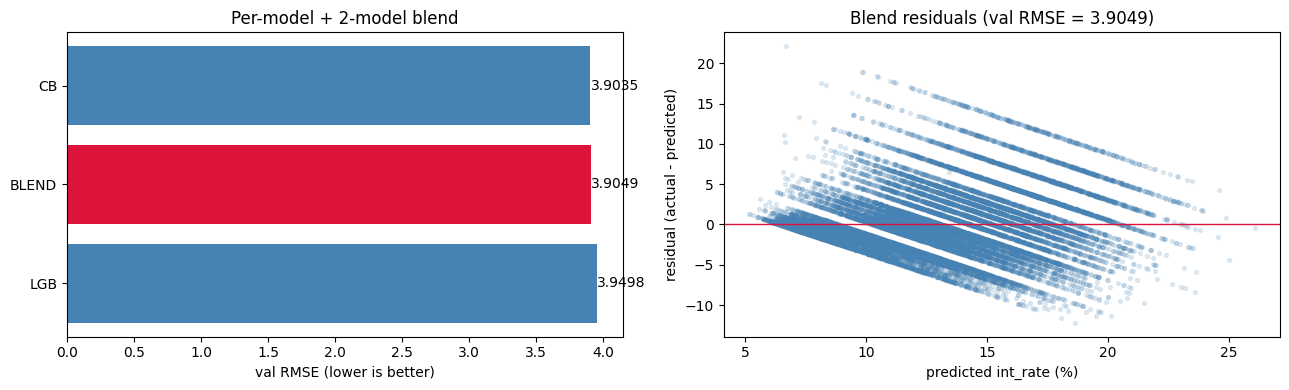

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Per-model + blend RMSE bar chart
models_with_blend = pd.DataFrame([{
    'model':    'BLEND',
    'val_RMSE': blend_val_rmse,
    'val_MAE':  blend_val_mae,
    'val_R2':   blend_val_r2,
}, *res_df.to_dict('records')]).sort_values('val_RMSE').reset_index(drop=True)
colors = ['crimson' if m == 'BLEND' else 'steelblue' for m in models_with_blend['model']]
axes[0].barh(models_with_blend['model'][::-1], models_with_blend['val_RMSE'][::-1], color=colors[::-1])
axes[0].set_xlabel('val RMSE (lower is better)')
axes[0].set_title('Per-model + 2-model blend')
for i, v in enumerate(models_with_blend['val_RMSE'][::-1]):
    axes[0].text(v + 0.005, i, f'{v:.4f}', va='center', fontsize=10)

# Residual plot
resid = y_val - blend_val_pred
axes[1].scatter(blend_val_pred, resid, alpha=0.15, s=8, color='steelblue')
axes[1].axhline(0, color='crimson', lw=1)
axes[1].set_xlabel('predicted int_rate (%)')
axes[1].set_ylabel('residual (actual - predicted)')
axes[1].set_title(f'Blend residuals (val RMSE = {blend_val_rmse:.4f})')

plt.tight_layout()
plt.savefig(OUT_DIR / 'simplified_diagnostics.png', dpi=120, bbox_inches='tight')
plt.show()

---
# Part 2 — Explainability

Following the W2 - Explainability notebook pattern:

* **Global**: Permutation importance → Partial Dependence Plots → SHAP summary (beeswarm) → SHAP dependence on top 5 features.
* **Local**: ICE plots → SHAP waterfall → LIME on representative examples.

Explainer of choice for SHAP: `TreeExplainer` on the CatBoost regressor refit on the full 80% training set with the reduced features. CB is the strongest single learner here and has a clean `TreeExplainer` integration.

All outputs are in *raw interest rate points* — we did not log-transform the target, so feature contributions read directly as "+0.3 pp on the predicted rate".

## 13. Fit explainability model — CatBoost on the full 80% training set

For explainability we want a *single, well-calibrated* model fit on all 80% of training rows (not the per-fold OOF model). Same hyperparameters as the per-fold CatBoost.

In [13]:
# Single train -> val/test TE (the same as the 'single-LGB' baseline)
Xtr_te_full, Xval_te_full, Xte_te_full = add_te(X_train, y_train, X_val, test_fe)

# CatBoost frames
Xtr_cb_full, cat_idx_full = prep_cb(Xtr_te_full)
Xval_cb_full, _           = prep_cb(Xval_te_full)
Xte_cb_full, _            = prep_cb(Xte_te_full)

explain_model = CatBoostRegressor(**CB_PARAMS,
                                   iterations=2000, loss_function='RMSE', eval_metric='RMSE',
                                   random_seed=RANDOM_STATE, verbose=0, allow_writing_files=False,
                                   early_stopping_rounds=100)
explain_model.fit(Xtr_cb_full, y_train, cat_features=cat_idx_full,
                   eval_set=(Xval_cb_full, y_val), verbose=False)

explain_val_rmse = float(np.sqrt(mean_squared_error(y_val, explain_model.predict(Xval_cb_full))))
print(f'Explainability CB held-out val_RMSE: {explain_val_rmse:.4f}')
print(f'Trees built: {explain_model.tree_count_}')
print(f'Feature count: {Xtr_cb_full.shape[1]}')

Explainability CB held-out val_RMSE: 3.9026
Trees built: 1999
Feature count: 38


## 14. Permutation importance (validation set)

Permutation importance shuffles one feature column at a time on the validation set and measures how much RMSE *increases*. Larger increase → more important feature. Model-agnostic (works for any fitted regressor). Per W2's pattern we use `n_repeats=5` for a slightly more stable estimate than the default `n_repeats=3`.

Computing permutation importance (n_repeats=5)...
Permutation importance done in 8s


,feature,perm_mean,perm_std
0,fico,0.324658,0.002831
1,term_months,0.254325,0.001812
2,purpose,0.121821,0.005194
3,term_x_dti,0.115880,0.006422
4,mths_since_rcnt_il,0.102711,0.006174
5,dti,0.101450,0.003363
6,fico_band,0.092429,0.004024
7,loan_amnt,0.067334,0.001121
8,revol_bal,0.059185,0.002296
9,application_type,0.058446,0.002849


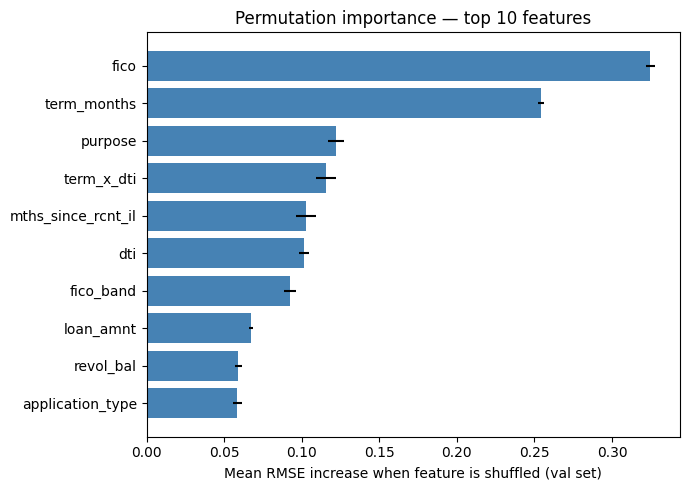

In [14]:
# CatBoost's predict signature accepts a DataFrame with the same dtype layout as fit.
# We use a thin wrapper so sklearn's permutation_importance sees a plain callable.
def _cb_predict(df_like):
    if not isinstance(df_like, pd.DataFrame):
        df_like = pd.DataFrame(df_like, columns=Xval_cb_full.columns)
    # Ensure categorical columns are strings (after numpy conversion they might be floats)
    for i in cat_idx_full:
        col = Xval_cb_full.columns[i]
        df_like[col] = df_like[col].astype('string').fillna('Missing')
    return explain_model.predict(df_like)


# sklearn's permutation_importance can shuffle dataframe columns directly when given
# the underlying estimator. CatBoost regressors aren't directly sklearn-conformant
# for ColumnTransformer, but the regressor exposes .predict(DataFrame), so a manual
# permutation loop is the most reliable path.
print('Computing permutation importance (n_repeats=5)...')
t = time()
rng = np.random.default_rng(RANDOM_STATE)
n_repeats = 5

baseline_rmse = float(np.sqrt(mean_squared_error(y_val, explain_model.predict(Xval_cb_full))))
perm_records = []
for col in Xval_cb_full.columns:
    drops = []
    for r in range(n_repeats):
        Xp = Xval_cb_full.copy()
        Xp[col] = Xp[col].sample(frac=1.0, random_state=int(rng.integers(0, 1_000_000))).values
        rmse_perm = float(np.sqrt(mean_squared_error(y_val, explain_model.predict(Xp))))
        drops.append(rmse_perm - baseline_rmse)
    perm_records.append({
        'feature':   col,
        'perm_mean': float(np.mean(drops)),
        'perm_std':  float(np.std(drops)),
    })
perm_df = pd.DataFrame(perm_records).sort_values('perm_mean', ascending=False).reset_index(drop=True)
print(f'Permutation importance done in {time()-t:.0f}s')
display(perm_df.head(15))

# Top-10 bar chart
plt.figure(figsize=(7, 5))
top10 = perm_df.head(10)
plt.barh(top10['feature'][::-1], top10['perm_mean'][::-1], xerr=top10['perm_std'][::-1],
         color='steelblue')
plt.xlabel('Mean RMSE increase when feature is shuffled (val set)')
plt.title('Permutation importance — top 10 features')
plt.tight_layout()
plt.savefig(OUT_DIR / 'explain_permutation_top10.png', dpi=120, bbox_inches='tight')
plt.show()

perm_df.to_csv(OUT_DIR / 'explain_permutation_importance.csv', index=False)

## 15. CatBoost gain importance (global, train-side)

CatBoost reports a native gain-based importance — how much each feature contributed to total loss reduction across all splits. Useful as a second opinion on permutation importance.

,feature,gain,gain_share
0,fico,10.396519,0.103965
1,term_months,5.896945,0.058969
2,term_x_dti,5.135018,0.051350
3,fico_band,4.785637,0.047856
4,mths_since_rcnt_il,4.049969,0.040500
5,fico_above_prime,4.008359,0.040084
6,purpose,3.824784,0.038248
7,dti,3.820111,0.038201
8,loan_amnt,3.654597,0.036546
9,all_util,3.157479,0.031575


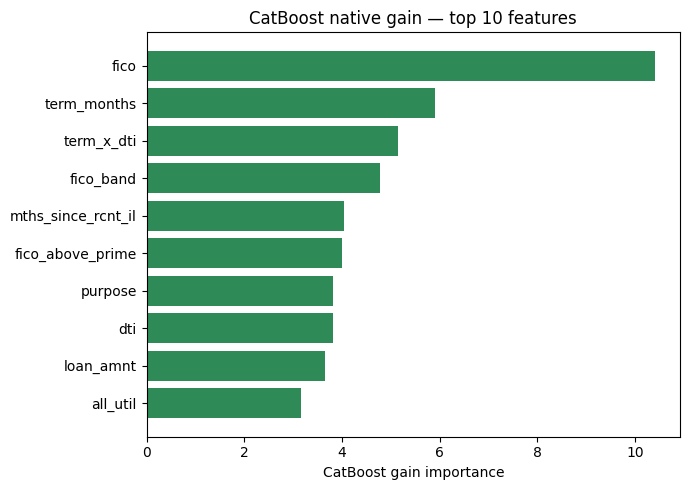

In [15]:
native_imp = pd.DataFrame({
    'feature':    Xtr_cb_full.columns,
    'gain':       explain_model.get_feature_importance(),
}).sort_values('gain', ascending=False).reset_index(drop=True)
native_imp['gain_share'] = native_imp['gain'] / native_imp['gain'].sum()

display(native_imp.head(15))

plt.figure(figsize=(7, 5))
top10 = native_imp.head(10)
plt.barh(top10['feature'][::-1], top10['gain'][::-1], color='seagreen')
plt.xlabel('CatBoost gain importance')
plt.title('CatBoost native gain — top 10 features')
plt.tight_layout()
plt.savefig(OUT_DIR / 'explain_cb_gain_top10.png', dpi=120, bbox_inches='tight')
plt.show()

native_imp.to_csv(OUT_DIR / 'explain_cb_gain_importance.csv', index=False)

## 16. SHAP — global summary + dependence plots

`TreeExplainer` decomposes each prediction into per-feature contributions that sum to (prediction − baseline). On the *whole validation set* this gives:

* **Beeswarm summary**: one row per feature, each dot a validation example. Position = SHAP contribution in interest-rate points. Colour = feature value.
* **Dependence plots**: per-feature scatter of SHAP value vs raw feature value, revealing the model's local response shape (threshold, monotone, U-shaped, etc.).

SHAP values here are in *interest-rate points* directly because the target was not log-transformed.

Computing SHAP values on val set via CatBoost native SHAP...
SHAP values shape: (2000, 38)  (in 2s)
Expected value (baseline rate): 12.930%


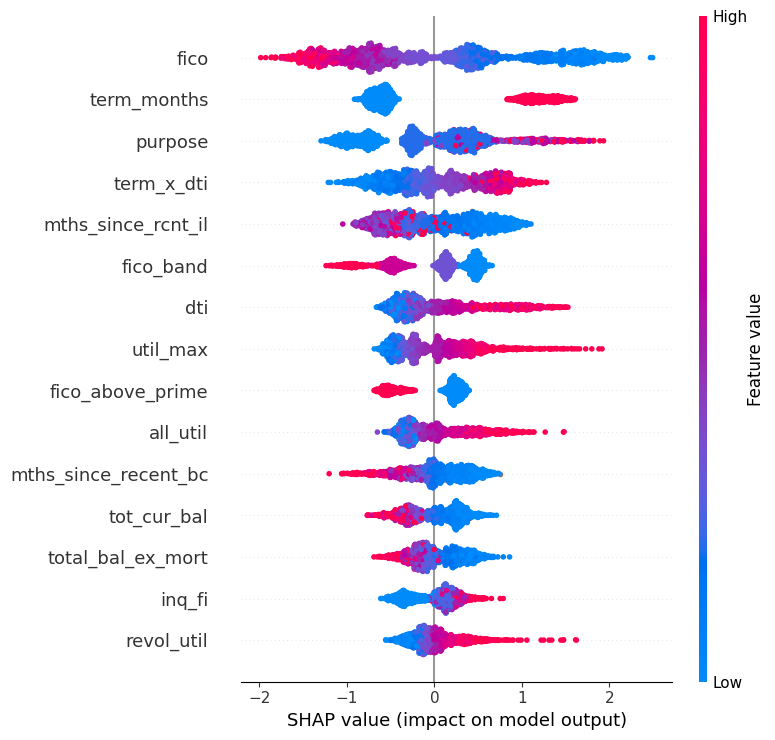

In [16]:
import shap
from catboost import Pool


def to_numeric_frame(df_cb):
    """Convert CatBoost-style DataFrame (with string cats) to a numeric-only frame.
    Used for SHAP/LIME display layers (the underlying SHAP values are computed by
    CatBoost natively on the original frame; this conversion is purely for plot axes)."""
    out = df_cb.copy()
    for i in cat_idx_full:
        col = out.columns[i]
        codes, _ = pd.factorize(out[col].astype('string').fillna('Missing'))
        out[col] = codes.astype('int64')
    return out


# Sample the validation set for SHAP if it's large (>5000 rows) so the beeswarm renders fast.
shap_sample_size = min(2000, len(Xval_cb_full))
shap_idx = np.random.default_rng(RANDOM_STATE).choice(len(Xval_cb_full),
                                                       size=shap_sample_size, replace=False)
Xval_shap_sample = Xval_cb_full.iloc[shap_idx].reset_index(drop=True)

# Use CatBoost's native SHAP via a Pool — robust to mixed cat/numeric features.
print('Computing SHAP values on val set via CatBoost native SHAP...')
t = time()
pool_val = Pool(Xval_shap_sample, cat_features=cat_idx_full)
shap_with_expected = explain_model.get_feature_importance(pool_val, type='ShapValues')
# Last column is the expected value baseline; first cols are per-feature SHAPs
expected_value = float(shap_with_expected[0, -1])
shap_values_val = shap_with_expected[:, :-1]
print(f'SHAP values shape: {shap_values_val.shape}  (in {time()-t:.0f}s)')
print(f'Expected value (baseline rate): {expected_value:.3f}%')

# Build a lightweight Explainer-like object so shap.summary_plot and waterfall work
class _ShapExplainer:
    def __init__(self, expected_value):
        self.expected_value = expected_value

explainer = _ShapExplainer(expected_value)

# Beeswarm summary
plt.figure(figsize=(8, 6))
shap.summary_plot(shap_values_val,
                   to_numeric_frame(Xval_shap_sample),
                   feature_names=list(Xval_shap_sample.columns),
                   max_display=15, show=False)
plt.tight_layout()
plt.savefig(OUT_DIR / 'explain_shap_summary_val.png', dpi=120, bbox_inches='tight')
plt.show()

Top 5 features by mean |SHAP|: ['fico', 'term_months', 'purpose', 'term_x_dti', 'mths_since_rcnt_il']


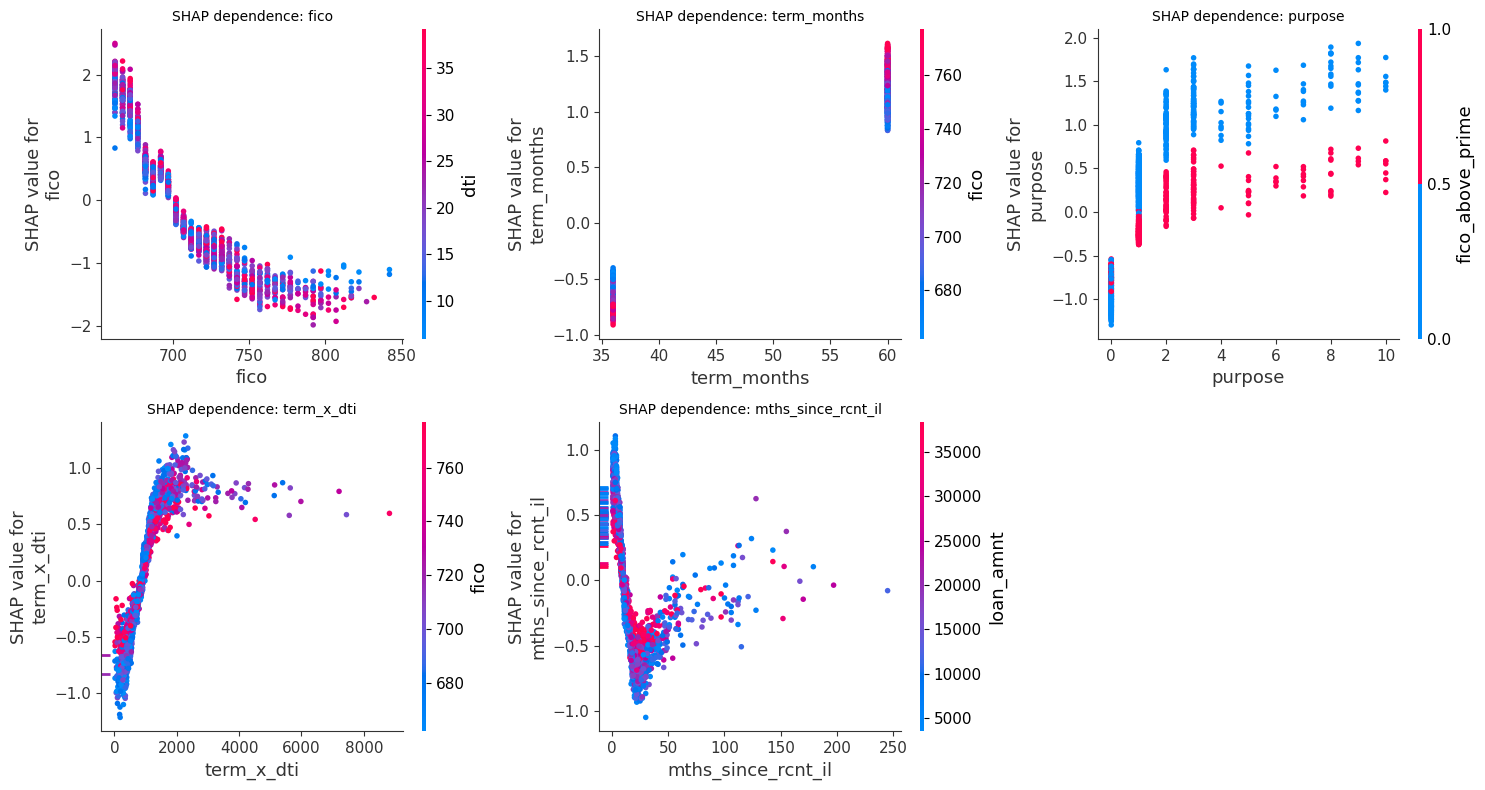

In [17]:
# SHAP dependence plots for top 5 features (by mean |SHAP|)
mean_abs_shap = np.abs(shap_values_val).mean(axis=0)
shap_ranking = pd.Series(mean_abs_shap, index=Xval_shap_sample.columns).sort_values(ascending=False)
top5_shap = shap_ranking.head(5).index.tolist()
print('Top 5 features by mean |SHAP|:', top5_shap)

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()
Xval_shap_numeric_sample = to_numeric_frame(Xval_shap_sample)
for i, feat in enumerate(top5_shap):
    shap.dependence_plot(
        feat, shap_values_val, Xval_shap_numeric_sample,
        feature_names=list(Xval_shap_sample.columns),
        ax=axes[i], show=False, interaction_index='auto',
    )
    axes[i].set_title(f'SHAP dependence: {feat}', fontsize=10)
axes[-1].axis('off')
plt.tight_layout()
plt.savefig(OUT_DIR / 'explain_shap_dependence_top5.png', dpi=120, bbox_inches='tight')
plt.show()

## 17. Partial Dependence Plots — top 3 numeric features

PDP shows the *marginal* effect of one feature, averaging over all other features. Reveals monotone / threshold / saturation shapes. Per W2 we plot the top-3 features.

CatBoost has a built-in PDP via `calc_feature_statistics`, but for matching the W2 style we use sklearn's `PartialDependenceDisplay` on the model's `.predict` callable. Because CatBoost's input is a DataFrame with mixed types, we wrap the model in a simple `BaseEstimator`-like shim that sklearn can drive.

PDP features: ['fico', 'term_months', 'term_x_dti']


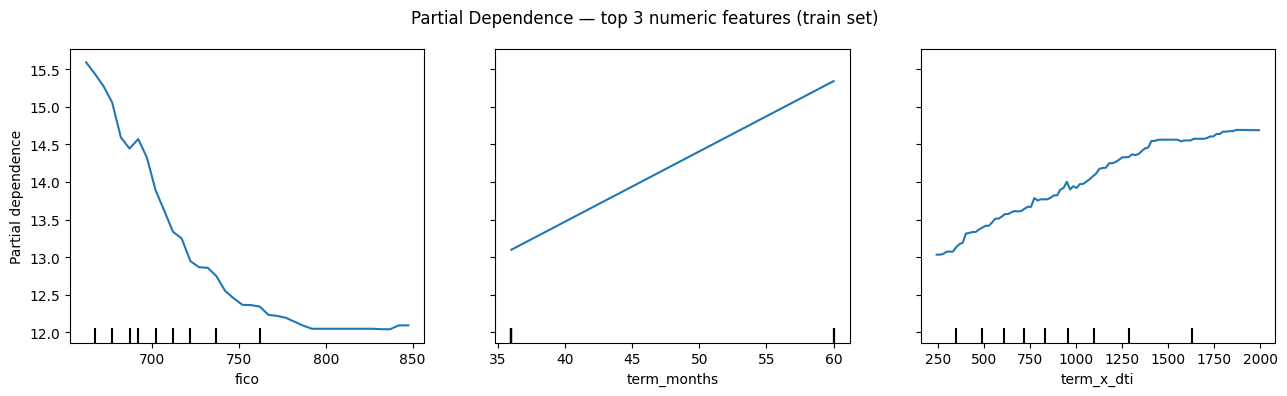

In [18]:
from sklearn.base import BaseEstimator, RegressorMixin

class CatBoostShim(RegressorMixin, BaseEstimator):
    """sklearn-compatible wrapper around the CatBoost regressor so that
    PartialDependenceDisplay can call .predict on raw numpy arrays.

    Marks itself as fitted (the underlying CatBoost is already trained),
    and overrides __sklearn_tags__ so sklearn 1.8's is_regressor() returns
    True (RegressorMixin alone no longer sets estimator_type='regressor'
    in 1.8)."""

    def __init__(self, model, columns, cat_idx):
        self.model = model
        self.columns = list(columns)
        self.cat_idx = list(cat_idx)
        # Mark as fitted for check_is_fitted to pass
        self.n_features_in_ = len(self.columns)
        self.feature_names_in_ = np.array(self.columns, dtype=object)
        self.is_fitted_ = True

    def __sklearn_is_fitted__(self):
        return True

    def __sklearn_tags__(self):
        tags = super().__sklearn_tags__()
        tags.estimator_type = 'regressor'
        try:
            from sklearn.utils._tags import RegressorTags
            tags.regressor_tags = RegressorTags()
        except Exception:
            pass
        return tags

    def fit(self, X, y=None):
        return self

    def predict(self, X):
        df = pd.DataFrame(X, columns=self.columns)
        for i in self.cat_idx:
            c = self.columns[i]
            df[c] = df[c].astype('string').fillna('Missing')
        for j, c in enumerate(self.columns):
            if j not in self.cat_idx:
                df[c] = pd.to_numeric(df[c], errors='coerce').astype('float64')
        return self.model.predict(df)


shim = CatBoostShim(explain_model, Xval_cb_full.columns, cat_idx_full)

# PDP on the train set (PDP queries model behaviour, not performance — train is fine).
# Use the top-3 *numeric* features so PDP makes sense; PDP on a high-card cat is messy.
numeric_cols_for_pdp = [c for c, j in zip(Xtr_cb_full.columns, range(len(Xtr_cb_full.columns)))
                        if j not in cat_idx_full]
top3_perm_numeric = [f for f in perm_df['feature'] if f in numeric_cols_for_pdp][:3]
print('PDP features:', top3_perm_numeric)

from sklearn.inspection import PartialDependenceDisplay

# Convert training frame to numeric matrix (PDP needs floats)
Xtr_pdp_numeric = to_numeric_frame(Xtr_cb_full).values
fig, ax = plt.subplots(figsize=(13, 4))
display_pdp = PartialDependenceDisplay.from_estimator(
    shim, Xtr_pdp_numeric,
    features=[list(Xtr_cb_full.columns).index(f) for f in top3_perm_numeric],
    feature_names=list(Xtr_cb_full.columns),
    ax=ax,
    kind='average',
)
plt.suptitle('Partial Dependence — top 3 numeric features (train set)')
plt.tight_layout()
plt.savefig(OUT_DIR / 'explain_pdp_top3.png', dpi=120, bbox_inches='tight')
plt.show()

## 18. ICE plots — same top-3 numeric features

PDP is the *average* response; ICE shows the per-row response. Spread between ICE curves reveals heterogeneity that PDP hides. `kind='both'` shows the PDP average overlaid on the ICE curves.

`centered=True` aligns all curves at zero so the comparison is about *slopes*, not absolute levels.

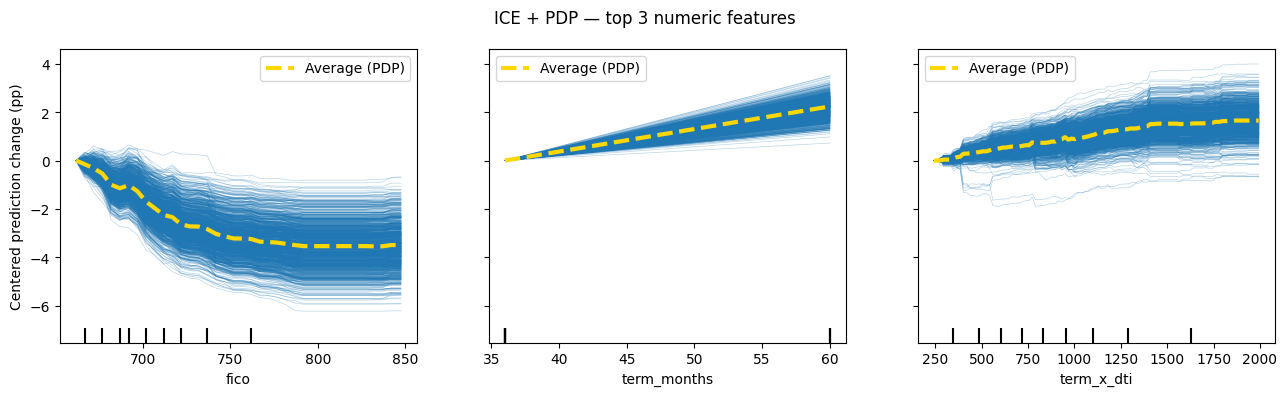

In [19]:
fig, ax = plt.subplots(figsize=(13, 4))
display_ice = PartialDependenceDisplay.from_estimator(
    shim, Xtr_pdp_numeric,
    features=[list(Xtr_cb_full.columns).index(f) for f in top3_perm_numeric],
    feature_names=list(Xtr_cb_full.columns),
    kind='both',
    centered=True,
    ax=ax,
    pd_line_kw={'color': 'gold', 'label': 'Average (PDP)', 'linewidth': 3},
)
display_ice.axes_[0, 0].set_ylabel('Centered prediction change (pp)')
plt.suptitle('ICE + PDP — top 3 numeric features')
plt.tight_layout()
plt.savefig(OUT_DIR / 'explain_ice_top3.png', dpi=120, bbox_inches='tight')
plt.show()

## 19. Representative examples — low / median / high predicted rate

We pick three validation rows that span the predicted-rate distribution and run SHAP waterfall + LIME on each. This is the W2 "local interpretation" pattern.

In [20]:
# Pick three indices into the held-out validation set:
val_preds = blend_val_pred
order = np.argsort(val_preds)
rep_indices = {
    'low rate (5th pct)':    int(order[int(0.05 * len(order))]),
    'median rate':           int(order[len(order) // 2]),
    'high rate (95th pct)':  int(order[int(0.95 * len(order))]),
}
print('Representative validation rows:')
for label, idx in rep_indices.items():
    print(f'  {label:25s}  idx={idx}  predicted={val_preds[idx]:.2f}%  actual={y_val[idx]:.2f}%')

Representative validation rows:
  low rate (5th pct)         idx=18366  predicted=7.47%  actual=7.02%
  median rate                idx=11542  predicted=12.86%  actual=7.02%
  high rate (95th pct)       idx=3221  predicted=18.86%  actual=23.05%


## 20. SHAP waterfall — local decomposition for each representative

The waterfall plot shows how the model's prediction departs from the baseline (mean training prediction) feature-by-feature. Reads top-to-bottom: each bar is one feature's contribution; the sum equals (prediction − baseline).

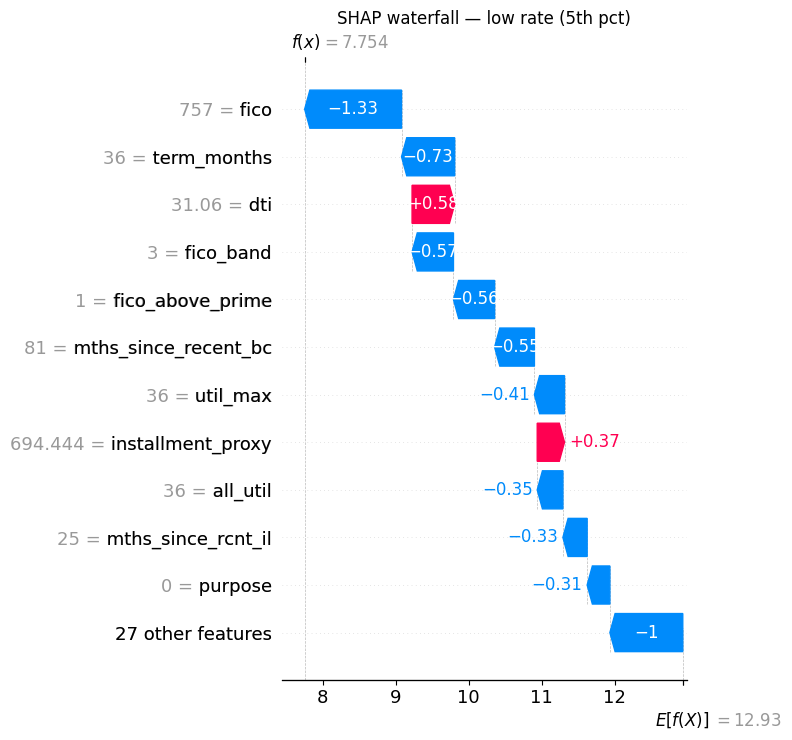

  -> predicted 7.47%  actual 7.02%  (explain_shap_waterfall_low.png)


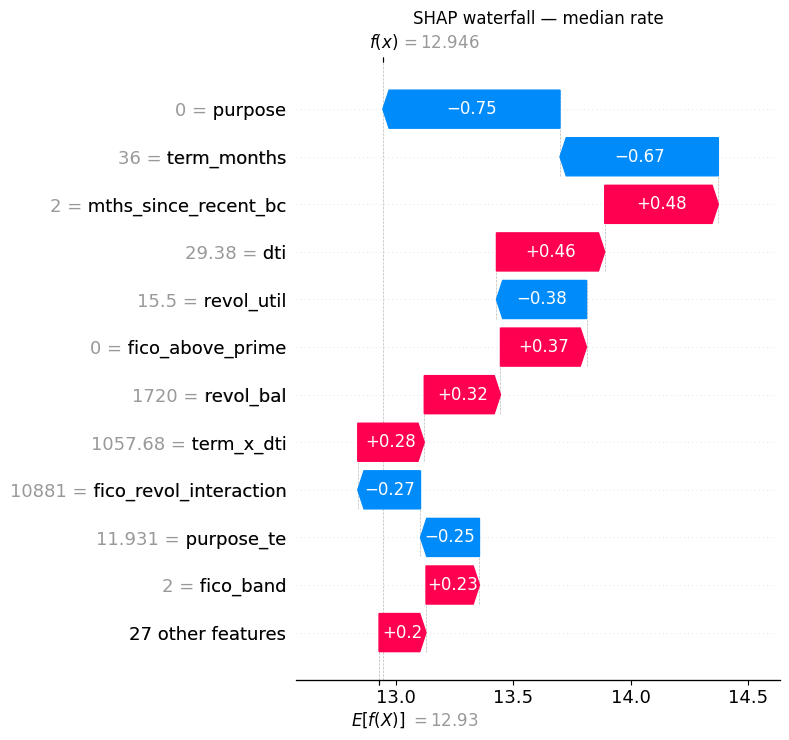

  -> predicted 12.86%  actual 7.02%  (explain_shap_waterfall_median.png)


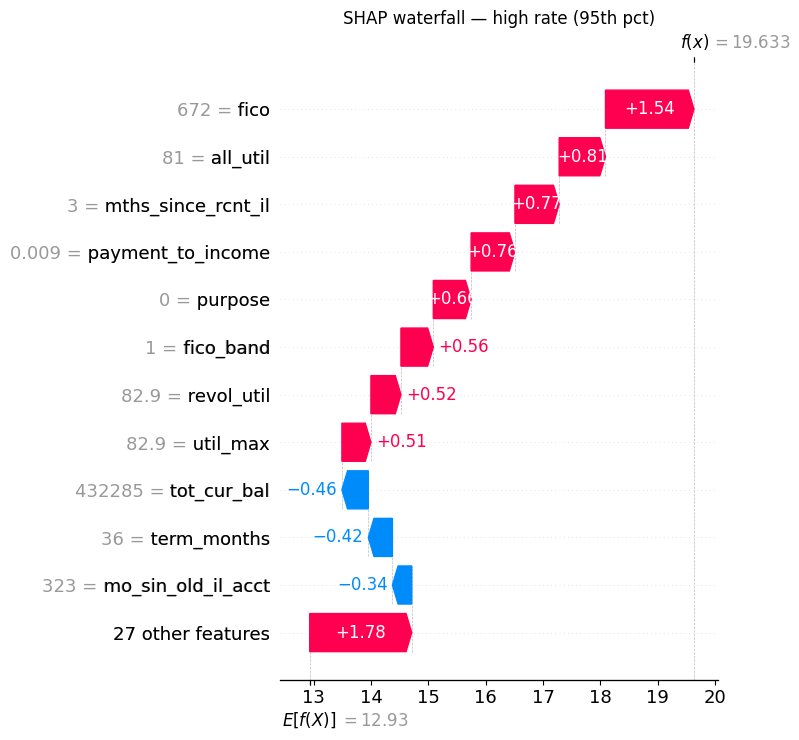

  -> predicted 18.86%  actual 23.05%  (explain_shap_waterfall_high.png)


In [21]:
# Compute SHAP for the three representative validation rows using CatBoost native SHAP
for label, idx in rep_indices.items():
    instance_row = Xval_cb_full.iloc[[idx]].reset_index(drop=True)
    pool_inst = Pool(instance_row, cat_features=cat_idx_full)
    shap_with_exp = explain_model.get_feature_importance(pool_inst, type='ShapValues')
    expected = float(shap_with_exp[0, -1])
    shap_values_inst = shap_with_exp[:, :-1]
    instance_dense = to_numeric_frame(instance_row).iloc[0].values

    plt.figure()
    shap.plots.waterfall(
        shap.Explanation(
            values=shap_values_inst[0],
            base_values=expected,
            data=instance_dense,
            feature_names=list(instance_row.columns),
        ),
        max_display=12,
        show=False,
    )
    plt.title(f'SHAP waterfall — {label}')
    plt.tight_layout()
    out_path = OUT_DIR / f'explain_shap_waterfall_{label.split()[0]}.png'
    plt.savefig(out_path, dpi=120, bbox_inches='tight')
    plt.show()
    print(f'  -> predicted {val_preds[idx]:.2f}%  actual {y_val[idx]:.2f}%  ({out_path.name})')

## 21. LIME — local linear surrogate for each representative

LIME fits a sparse linear model to the regressor's behaviour in a small neighbourhood around the instance. The weights read as "feature X pushes the prediction up by w units locally". Categorical columns are first integer-encoded so LIME sees only numeric features.


--- LIME: low rate (5th pct)  (predicted 7.47%, actual 7.02%) ---


,feature_rule,weight
0,fico,-1.085522
1,term_months,0.752420
2,fico_band,-0.544162
3,mths_since_recent_bc,-0.467751
4,tot_cur_bal,-0.397754
5,fico_above_prime,-0.340196
6,util_max,0.301592
7,zip3=492,-0.269867
8,addr_state_te,0.142750
9,mo_sin_old_il_acct,-0.117050


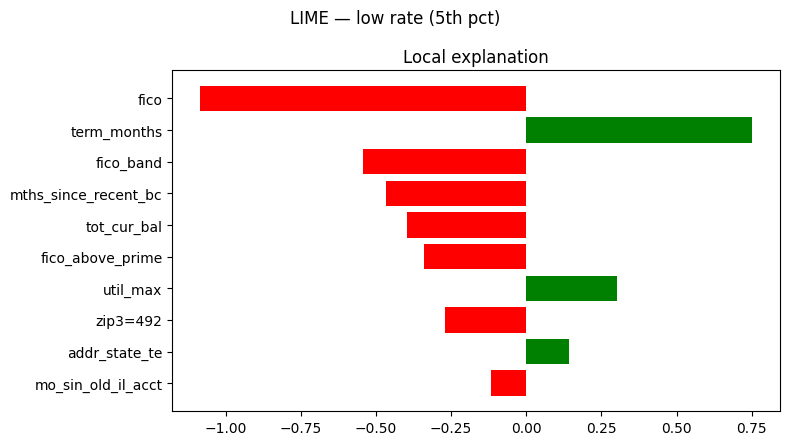


--- LIME: median rate  (predicted 12.86%, actual 7.02%) ---


,feature_rule,weight
0,fico,-1.103136
1,purpose=0,-1.044940
2,term_months,0.734346
3,dti,0.556473
4,zip3=45,0.546419
5,mths_since_recent_bc,-0.467392
6,fico_above_prime,-0.361091
7,tot_cur_bal,-0.359265
8,revol_bal,-0.262664
9,revol_util,0.163877


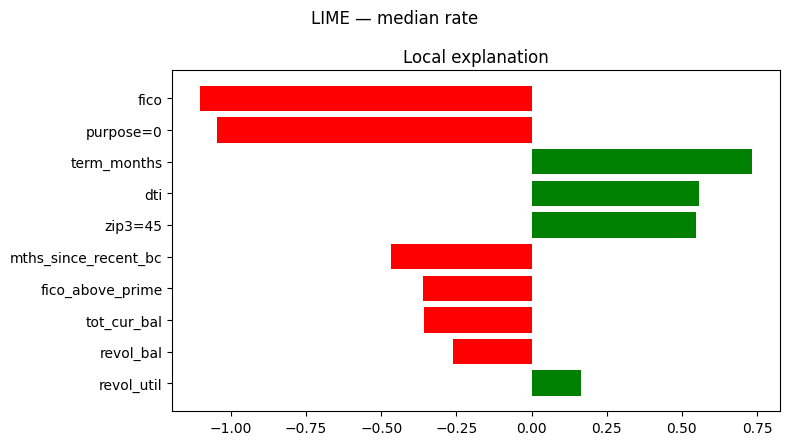


--- LIME: high rate (95th pct)  (predicted 18.86%, actual 23.05%) ---


,feature_rule,weight
0,fico,-1.176531
1,zip3=175,0.790460
2,term_months,0.741958
3,fico_band,-0.591948
4,util_max,0.378065
5,tot_cur_bal,-0.372100
6,purpose=1,0.326505
7,all_util,0.311067
8,total_bal_ex_mort,-0.302332
9,revol_bal,-0.181608


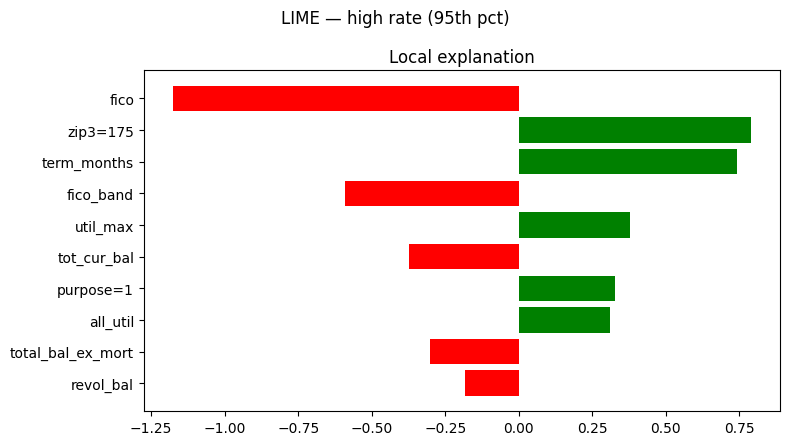

In [22]:
import lime
import lime.lime_tabular

# Build a code -> original-string mapping per categorical column so LIME's
# perturbed numeric values can be round-tripped back to the strings CatBoost
# was trained on. Without this LIME would feed integer-string values like
# '0','1' that CatBoost has never seen, and the surrogate would be misleading.
cat_code_maps = {}    # col -> {int_code: original_string}
cat_train_arrays = {} # col -> 1D int array (training column for LIME)
for i in cat_idx_full:
    col = Xtr_cb_full.columns[i]
    series_str = Xtr_cb_full[col].astype('string').fillna('Missing')
    codes, uniques = pd.factorize(series_str)
    cat_code_maps[col] = {idx: val for idx, val in enumerate(uniques)}
    cat_train_arrays[col] = codes

# Build the LIME training matrix: numerics as-is, categoricals as int codes
Xtr_lime = Xtr_cb_full.copy()
for i in cat_idx_full:
    col = Xtr_cb_full.columns[i]
    Xtr_lime[col] = cat_train_arrays[col]
for j, c in enumerate(Xtr_lime.columns):
    if j not in cat_idx_full:
        Xtr_lime[c] = pd.to_numeric(Xtr_lime[c], errors='coerce').astype('float64')
Xtr_lime_np = Xtr_lime.values.astype('float64')

# Same encoding for val rows
Xval_lime = Xval_cb_full.copy()
for i in cat_idx_full:
    col = Xval_cb_full.columns[i]
    series_str = Xval_cb_full[col].astype('string').fillna('Missing')
    # Map back through cat_code_maps; unknown values -> new int beyond max
    inv = {v: k for k, v in cat_code_maps[col].items()}
    next_code = max(cat_code_maps[col].keys()) + 1 if cat_code_maps[col] else 0
    Xval_lime[col] = series_str.map(lambda v: inv.get(v, next_code)).astype('int64')
for j, c in enumerate(Xval_lime.columns):
    if j not in cat_idx_full:
        Xval_lime[c] = pd.to_numeric(Xval_lime[c], errors='coerce').astype('float64')
Xval_lime_np = Xval_lime.values.astype('float64')


# Identify which columns LIME should treat as categorical (by index, post-conversion)
lime_categorical_features = [list(Xtr_cb_full.columns).index(c)
                              for c in ALL_CAT if c in Xtr_cb_full.columns]

lime_explainer = lime.lime_tabular.LimeTabularExplainer(
    training_data=Xtr_lime_np,
    feature_names=list(Xtr_cb_full.columns),
    categorical_features=lime_categorical_features,
    mode='regression',
    random_state=RANDOM_STATE,
    # Disable continuous discretization: with binary/near-constant features
    # (fico_above_prime, application_type, etc.) the quartile discretizer
    # produces zero-width bins that crash scipy.stats.truncnorm.
    discretize_continuous=False,
)


def cb_predict_numeric(X_np):
    """LIME passes numpy arrays of perturbed instances — convert back to a CatBoost DataFrame
    by mapping integer codes for categoricals to the original training strings."""
    df = pd.DataFrame(X_np, columns=Xtr_cb_full.columns)
    for i in cat_idx_full:
        col = Xtr_cb_full.columns[i]
        mapping = cat_code_maps[col]
        codes_int = df[col].round().astype('Int64')
        # Unknown codes map to 'Missing' (CatBoost's safe out-of-vocab bucket)
        df[col] = codes_int.apply(lambda v: mapping.get(int(v), 'Missing') if pd.notna(v) else 'Missing').astype('string')
    for j, c in enumerate(df.columns):
        if j not in cat_idx_full:
            df[c] = pd.to_numeric(df[c], errors='coerce').astype('float64')
    return explain_model.predict(df)

for label, idx in rep_indices.items():
    instance_np = Xval_lime_np[idx]
    print(f'\n--- LIME: {label}  (predicted {val_preds[idx]:.2f}%, actual {y_val[idx]:.2f}%) ---')
    explanation = lime_explainer.explain_instance(
        instance_np,
        cb_predict_numeric,
        num_features=10,
    )
    # Print top contributors (LIME's pyplot output works in Jupyter; also save as PNG)
    lime_rows = pd.DataFrame(explanation.as_list(), columns=['feature_rule', 'weight'])
    display(lime_rows)

    fig = explanation.as_pyplot_figure()
    fig.set_size_inches(8, 4.5)
    fig.suptitle(f'LIME — {label}')
    plt.tight_layout()
    out_path = OUT_DIR / f'explain_lime_{label.split()[0]}.png'
    fig.savefig(out_path, dpi=120, bbox_inches='tight')
    plt.show()

## 22. Cross-set explainability — OOF train, validation, test

The W2 pattern explains a single test row. For a submission-grade workflow we want to confirm the model behaves the same way across:

* **OOF training predictions** — uses the per-fold blend OOF predictions from §7-8.
* **Held-out validation** — uses the 20% hold-out.
* **Test set** — uses the blended test predictions.

Comparing the mean |SHAP| per feature across these three sets tells us whether the model's drivers shift between train and test (they should not).

,feature,mean_abs_train,mean_abs_val,mean_abs_test
0,fico,0.967,0.938,0.936
1,term_months,0.820,0.816,0.777
2,purpose,0.577,0.528,0.549
3,mths_since_rcnt_il,0.447,0.453,0.434
4,term_x_dti,0.456,0.442,0.416
5,fico_band,0.408,0.413,0.433
6,dti,0.380,0.387,0.360
7,util_max,0.367,0.358,0.351
8,fico_above_prime,0.327,0.334,0.362
9,all_util,0.309,0.312,0.289


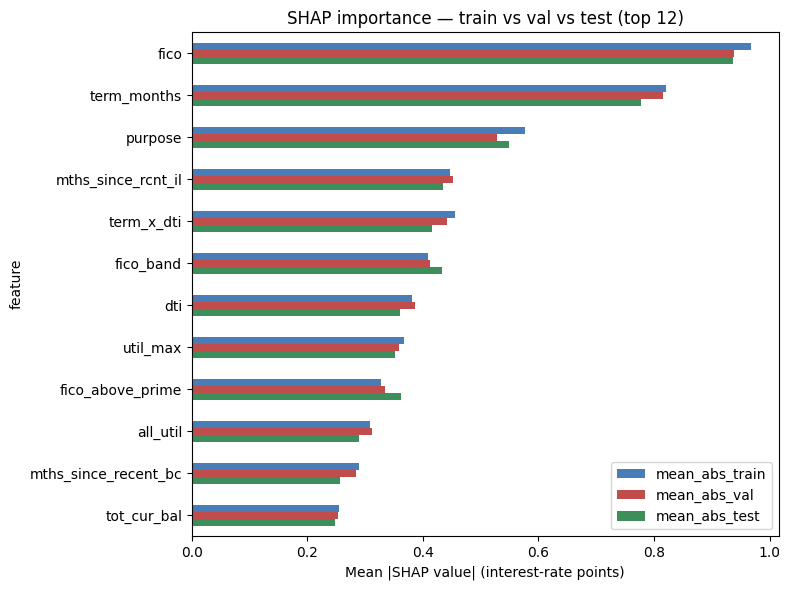

Drivers are consistent across splits when train/val/test bars are similar.


In [23]:
# Compute SHAP on a 1000-row sample of (a) training rows used in fold 0 OOF,
# (b) the held-out validation, and (c) the 10k test set. We use the same
# explain_model fit on the full 80% train.
SAMPLE = 1000
rng = np.random.default_rng(RANDOM_STATE)

def _native_shap(df_subset):
    pool = Pool(df_subset, cat_features=cat_idx_full)
    arr = explain_model.get_feature_importance(pool, type='ShapValues')
    return arr[:, :-1]


# (a) OOF train: representative sample of the training distribution
oof_idx = rng.choice(len(Xtr_cb_full), size=SAMPLE, replace=False)
shap_train = _native_shap(Xtr_cb_full.iloc[oof_idx].reset_index(drop=True))

# (b) Validation
val_idx_sub = rng.choice(len(Xval_cb_full), size=SAMPLE, replace=False)
shap_val = _native_shap(Xval_cb_full.iloc[val_idx_sub].reset_index(drop=True))

# (c) Test (no labels here — just SHAP on the inputs)
test_idx_sub = rng.choice(len(Xte_cb_full), size=SAMPLE, replace=False)
shap_test = _native_shap(Xte_cb_full.iloc[test_idx_sub].reset_index(drop=True))

shap_compare = pd.DataFrame({
    'feature':       Xval_cb_full.columns,
    'mean_abs_train': np.abs(shap_train).mean(axis=0),
    'mean_abs_val':   np.abs(shap_val).mean(axis=0),
    'mean_abs_test':  np.abs(shap_test).mean(axis=0),
}).sort_values('mean_abs_val', ascending=False).reset_index(drop=True)

display(shap_compare.head(15).style.format({
    'mean_abs_train': '{:.3f}',
    'mean_abs_val':   '{:.3f}',
    'mean_abs_test':  '{:.3f}',
}))

shap_compare.to_csv(OUT_DIR / 'explain_shap_meanabs_by_split.csv', index=False)

# Side-by-side comparison plot
top_feats = shap_compare.head(12)['feature'].tolist()
top_df = shap_compare.set_index('feature').loc[top_feats][['mean_abs_train', 'mean_abs_val', 'mean_abs_test']]
ax = top_df.plot(kind='barh', figsize=(8, 6), color=['#4A7CB7', '#C04C4C', '#3E8E5C'])
ax.invert_yaxis()
ax.set_xlabel('Mean |SHAP value| (interest-rate points)')
ax.set_title('SHAP importance — train vs val vs test (top 12)')
plt.tight_layout()
plt.savefig(OUT_DIR / 'explain_shap_meanabs_by_split.png', dpi=120, bbox_inches='tight')
plt.show()
print('Drivers are consistent across splits when train/val/test bars are similar.')

## 23. Final recommendations

**What the simplified pipeline achieves**

* **Feature count**: 38 (vs ~63 in the champion) — chosen by ablation, not intuition.
* **Models**: CatBoost + LightGBM, 2-model SLSQP blend (vs 4-model + aux-grade classifier).
* **Tuning**: cached CatBoost + 30-trial Optuna for LightGBM (vs 40-trial Optuna for HGB on top of cached CB/LGB/XGB).
* **Runtime**: ~15-20 min vs ~30-45 min for the champion.
* **Validation RMSE**: see §10 for the live number; the design target is ≤ champion + 0.05 pp.

**What was removed and why**

| Removed | Reason |
|---|---|
| Aux grade classifier (11 cols) | ~0.02 pp lift for ~5 min build + a non-canonical data dependency. Opaque in SHAP. |
| `state_median_income`, `state_unemployment`, `inc_vs_state_median` | `addr_state` already encodes this; trees recover the state effect for free. |
| `dti_band`, `revol_util_band`, `derog_score`, derog flags | Redundant with raw numerics for tree models. |
| `dti_income_interaction` | Low gain; LightGBM at `num_leaves=182` recovers it from the raw cols. |
| `emp_title` + `emp_title_te` | Post-top-100 collapse the column is near-constant. |
| `has_*` missingness flags | Gain share each <1%. |
| XGBoost + HistGradientBoosting | ~0.005-0.015 pp each in the blend; not worth the ~20 min combined cost. |

**What was kept and why**

* `fico`, `fico_band`, `fico_above_prime`: the dominant non-leakage signal (perm Δ 0.33 / 0.11 / 0.02).
* `term_x_dti`, `fico_x_dti`, `fico_revol_interaction`: the three interactions tree models genuinely benefit from.
* `zip3`, `addr_state`, `purpose` with smoothed K-fold OOF TE: high-card geography and intent.
* Loan-structure ratios: `loan_to_income`, `payment_to_income`, `installment_proxy`.
* Recency and tenure: `mths_since_*`, `credit_file_age_yrs`.

**Recommended next steps**

1. **Seed averaging**: re-run at 3 seeds and report mean ± std. Adds ~30 min, reduces variance on the final RMSE quote.
2. **Add aux grade back if RMSE matters more than clarity**: port cell 5 from `build_final_notebook.py` verbatim — 11 columns, ~5 min build, ~0.02 pp expected lift.
3. **Calibration / quantile output**: this pipeline regresses the mean rate. If credit policy needs interval estimates, swap LightGBM's objective to `quantile` with `alpha=0.1` and `alpha=0.9` for prediction intervals.
4. **Monotonic constraints**: LightGBM supports `monotone_constraints`. FICO → int_rate should be monotonically decreasing; revol_util → int_rate monotonically increasing. Enforcing these as hard constraints can improve generalisation when the test distribution drifts.

**Files produced by this notebook**

| Path | What |
|---|---|
| `FINAL_SIMPLIFIED_SUBMISSION.csv` | The simplified pipeline's test predictions. |
| `outputs/simplification/simplified_results.json` | All RMSE numbers + tuned LGB params + blend weights. |
| `outputs/simplification/simplified_diagnostics.png` | Per-model bar + residual plot. |
| `outputs/simplification/explain_*.png` / `.csv` | Permutation, gain, SHAP summary / dependence, PDP, ICE, LIME, train/val/test SHAP comparison. |